# Максимален поток и най-кратък път

Отвори в Colab: [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)]({{< var colabPrefix >}}06-02-Max-Flow-Shortest-Path.ipynb)


In [1]:
%pip install --quiet gurobipy

/home/amarov/stats/opt2026/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np

# Създаваме нов ориентиран граф
G = nx.DiGraph()

# Добавяме възли с координати
positions = {
    'A': (0, 0),
    'B': (1, 2),
    'C': (2, 1),
    'D': (3, 3),
    'E': (4, 1),
    'F': (5, 2),
    'T': (6, 0),
    'H': (2, -1),
    'I': (4, -1),
    'J': (5, 3)
}

# Добавяме дъги с тегла
edges = [
    ('A', 'B', 9, 2, 0.001),
    ('A', 'C', 14, 3, 0.002),
    ('B', 'D', 7, 4, 0.003),
    ('C', 'D', 16, 1, 0.001),
    ('C', 'E', 20, 5, 0.001),
    ('D', 'F', 18, 2, 0.005),
    ('E', 'F', 10, 3, 0.002),
    ('F', 'T', 11, 1, 0.010),
    ('A', 'H', 23, 4, 0.008),
    ('H', 'C', 13, 2, 0.006),
    ('H', 'I', 12, 3, 0.002),
    ('I', 'E', 15, 2, 0.001),
    ('I', 'T', 25, 4, 0.002),
    ('D', 'J', 24, 3, 0.002),
    ('J', 'F', 18, 2, 0.008)
]

# Добавяме дъгите в графа
for u, v, c, w, prob in edges:
    G.add_edge(u, v, Capacity=c, Distance=w, Probability=prob)


In [3]:
def visualize_graph(G, positions, edge_attribute: str, title: str):

    if edge_attribute not in G.edges[next(iter(G.edges))]:
        raise ValueError(f"Графът няма атрибут '{edge_attribute}' за дъгите. Моля, изберете валиден атрибут от {list(G.edges[next(iter(G.edges))].keys())}.")
    
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos=positions, with_labels=True, node_size=700, node_color='lightblue', font_size=10, font_weight='bold', arrows=True)

    # Етикетите на дъгите
    edge_labels = nx.get_edge_attributes(G, edge_attribute)
    nx.draw_networkx_edge_labels(G, pos=positions, edge_labels=edge_labels, rotate=False)

    for node, (x, y) in positions.items():
        circle = mpatches.Circle((x, y), radius=0.2, color='lightblue', alpha=0.5)
        plt.gca().add_patch(circle)

    plt.xlim(-1, 7)
    plt.ylim(-2, 5)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(title)
    plt.grid()
    plt.show()



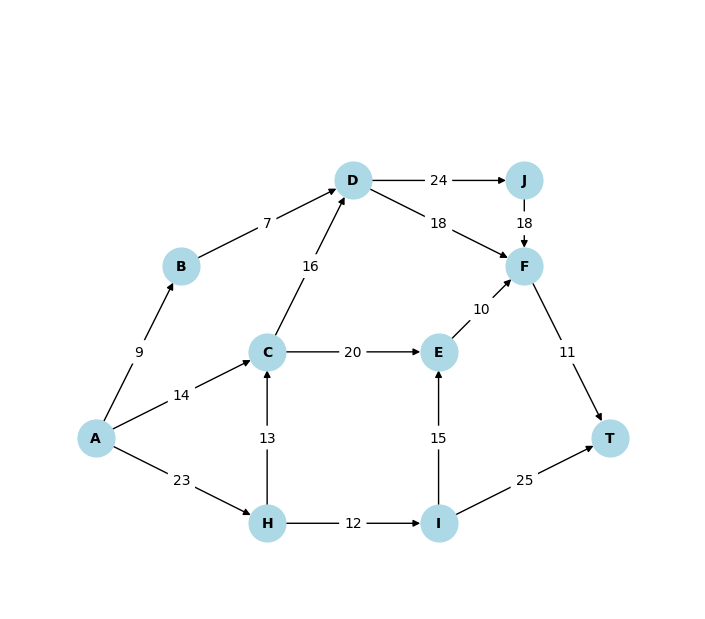

In [4]:
#| label: fig-graph-max-flow
#| fig-cap: "Водопреносна мрежа с капацитети на дъгите с начало в A и край в G. Стойностите на дъгите показват преносния им капацитет."

visualize_graph(G, positions, "Capacity", title='')

## Най-голям поток (Maximum Flow)

Първо ще разгледаме класически проблем за намиране на най-големия поток в мрежа. Може да си представим, че @fig-graph-max-flow показва мрежа от водопроводни тръби, където всяка дъга има определен капацитет (стойностите на дъгите), който показва максималното количество вода, което може да премине през нея. Целта е да се определи колко вода може да се пренесе от началния възел A (източник, source) до крайния възел T (приемник, sink, target), като се спазват капацитетите на дъгите.

- Формулирайте проблема като задача за линейна оптимизация (LP)
- Решете задачата в [Excel](./excel/Max-Flow-Capacities.xlsx) и сравнете резултата си с решението, получено с Gurobi.


:::{.callout-note collapse="true"}
## Решение

Нека $x_{ij} \geq 0, i,j \in \{A, B, C, D, E, F, H, I, J, T\}$ са променливи, които показват поток с начален връх $i$ и посока $j$. Целта ни е да намерим колко е възможно най-големия поток от източника A към крайната точка T.

Целевата функция е потокът в крайния възел T:

$$
\begin{align*}
\text{Maximize} \quad & x_{FT} + x_{IT}
\end{align*}
$$

Потоците между възлите не могат да надвишават капацитета на съответните дъги (следващите неравенства описват това ограничение за първите три и последните две дъги, останалите са аналогично):

$$
\begin{align*}
x_{AB} &\leq 9 \\
x_{AC} &\leq 14 \\
x_{AH} &\leq 23 \\
\vdots \\
x_{IT} &\leq 25 \\
x_{FT} &\leq 11
\end{align*}
$$

Потоците в мрежата трябва да отговарят и на балансовото ограничение, което гласи, че за всеки възел (освен източника и приемника) сумата от входящите потоци трябва да е равна на сумата от изходящите потоци. Например, за възлите B  и C това означава:

$$
\begin{align*}
x_{АB} & = x_{BD}\\
x_{AC} + x_{HC} & = x_{CD} + x_{CE}
\end{align*}
$$

:::


In [5]:
import gurobipy as gp
from gurobipy import GRB

mf = gp.Model("MaxFlow")
mf.setParam('LogToConsole', 0)  # Изключваме изхода на Gurobi за по-чист резултат

# Създаваме променливи за поток на всяка дъга
flow = mf.addVars(G.edges(), name="Flow")

# Ограничения за капацитетите на дъгите
for u, v in G.edges():
    mf.addConstr(flow[u, v] <= G.edges[u, v]['Capacity'], name=f"Cap_{u}_{v}")

# Ограничения за запазване на потока (flow conservation)
for node in G.nodes():
    inflow = gp.quicksum(flow[u, node] for u in G.predecessors(node))
    outflow = gp.quicksum(flow[node, v] for v in G.successors(node))
    
    # Само за вътрешни възли, потокът влизащ = потокът излизащ
    if node != 'A' and node != 'T':
        mf.addConstr(inflow == outflow, name=f"FlowConservation_{node}")

# Целева функция: максимизиране на потока от A до T
mf.setObjective(gp.quicksum(flow[v, "T"] for v in G.predecessors("T")), GRB.MAXIMIZE)

mf.optimize()

Restricted license - for non-production use only - expires 2027-11-29
Set parameter LogToConsole to value 0


In [6]:
if mf.status == GRB.OPTIMAL:
    print(f"Максимален поток от A до T: {mf.objVal}")
    for u, v in G.edges():
        if flow[u, v].x > 0.01:  # Показваме само значими потоци
            print(f"Поток по дъгата {u} -> {v}: {flow[u, v].x}")
else:
    print("Не е намерено оптимално решение.")

Максимален поток от A до T: 23.0
Поток по дъгата A -> B: 1.0
Поток по дъгата A -> C: 10.0
Поток по дъгата A -> H: 12.0
Поток по дъгата B -> D: 1.0
Поток по дъгата C -> E: 10.0
Поток по дъгата D -> J: 1.0
Поток по дъгата E -> F: 10.0
Поток по дъгата F -> T: 11.0
Поток по дъгата H -> I: 12.0
Поток по дъгата I -> T: 12.0
Поток по дъгата J -> F: 1.0


In [7]:
mf.write("__max_flow_model.lp")

with open("__max_flow_model.lp", "r") as f:
    print(f.read())


\ Model MaxFlow
\ LP format - for model browsing. Use MPS format to capture full model detail.
Maximize
  Flow[F,T] + Flow[I,T]
Subject To
 Cap_A_B: Flow[A,B] <= 9
 Cap_A_C: Flow[A,C] <= 14
 Cap_A_H: Flow[A,H] <= 23
 Cap_B_D: Flow[B,D] <= 7
 Cap_C_D: Flow[C,D] <= 16
 Cap_C_E: Flow[C,E] <= 20
 Cap_D_F: Flow[D,F] <= 18
 Cap_D_J: Flow[D,J] <= 24
 Cap_E_F: Flow[E,F] <= 10
 Cap_F_T: Flow[F,T] <= 11
 Cap_H_C: Flow[H,C] <= 13
 Cap_H_I: Flow[H,I] <= 12
 Cap_I_E: Flow[I,E] <= 15
 Cap_I_T: Flow[I,T] <= 25
 Cap_J_F: Flow[J,F] <= 18
 FlowConservation_B: Flow[A,B] - Flow[B,D] = 0
 FlowConservation_C: Flow[A,C] - Flow[C,D] - Flow[C,E] + Flow[H,C] = 0
 FlowConservation_D: Flow[B,D] + Flow[C,D] - Flow[D,F] - Flow[D,J] = 0
 FlowConservation_E: Flow[C,E] - Flow[E,F] + Flow[I,E] = 0
 FlowConservation_F: Flow[D,F] + Flow[E,F] - Flow[F,T] + Flow[J,F] = 0
 FlowConservation_H: Flow[A,H] - Flow[H,C] - Flow[H,I] = 0
 FlowConservation_I: Flow[H,I] - Flow[I,E] - Flow[I,T] = 0
 FlowConservation_J: Flow[D,J] - Flo

In [8]:
# Създаваме pandas DataFrame за дъгите и техните атрибути

import pandas as pd
# Създаваме DataFrame от списъка с дъги
dt = pd.DataFrame(edges, columns=['Source', 'Target', 'Capacity', 'Distance', 'Probability']).set_index(['Source', 'Target'])

# Преобразуваме в таблица: редове = Source, колони = Target, стойности = Distance
distance_table = dt['Distance'].unstack('Target')
distance_table.to_excel('./excel/Shortest-Path-Distances.xlsx')  # Запазваме таблицата с разстояния в Excel файл

capacity_table = dt['Capacity'].unstack('Target')
capacity_table.to_excel('./excel/Max-Flow-Capacities.xlsx')

# dt

In [9]:
# Вземаме всички уникални стойности от многоиндекс
def get_unique_values(df):
    # Вземаме уникалните стойности от многоиндекса
    unique_values = set()
    for index in df.index:
        unique_values.update(index)
    return unique_values

nodes = get_unique_values(dt)

nodes

{'A', 'B', 'C', 'D', 'E', 'F', 'H', 'I', 'J', 'T'}

In [19]:
# Оптимизационен модел в gurobi за задачата за най-кратък път

import gurobipy as gp
from gurobipy import GRB

# Създаваме нов модел
m = gp.Model("ShortestPath")
m.params.logToConsole = 0  # Изключваме изхода на Gurobi за по-чист резултат
# Създаваме променливи за всяка дъга
x = m.addVars(dt.index, vtype=GRB.BINARY, name="x")

# Задаваме целева функция за минимизиране на общото разстояние
m.setObjective(x.prod(dt['Capacity'].to_dict()), GRB.MINIMIZE)

# Добавяме ограничения за запазване на потока

# За всеки възел входящият поток трябва да е равен на изходящия поток

m.addConstr(x.sum("A", '*') == 1, name=f"Leave_A")  # Изходен възел

m.addConstr(x.sum('*', "T") == 1, name=f"Arrive_T")  # Краен възел

for node in nodes:
    if node in ['A', 'T']:
        continue
    
    inflow = x.sum('*', node)
    outflow = x.sum(node, '*')
    m.addConstr(outflow == inflow, name=f"ConserveFlow_{node}")
    # m.addConstr(x.sum(node, '*') <= 1, name=f"outflow_{node}")
    # m.addConstr(x.sum('*', node) <= 1, name=f"infow_{node}")

# Добавяме ограничения, че потокът е двоичен

m.optimize()

Set parameter LogToConsole to value 0


In [20]:
# Отпечатване на резултатите
if m.status == GRB.OPTIMAL:
    print('Намерено е оптимално решение:')
    for v in m.getVars():
        if v.x > 0:
            print(f'{v.varName}: {v.x}')

    print(f'Стойност на целевата функция: {m.objVal}')
else:
    print('Не е намерено оптимално решение.')

Намерено е оптимално решение:
x[A,B]: 1.0
x[B,D]: 1.0
x[D,F]: 1.0
x[F,T]: 1.0
Стойност на целевата функция: 45.0


In [21]:
m.write("shortest_path.lp")

with open("shortest_path.lp", "r") as file:
    print(file.read())

\ Model ShortestPath
\ LP format - for model browsing. Use MPS format to capture full model detail.
Minimize
  9 x[A,B] + 14 x[A,C] + 7 x[B,D] + 16 x[C,D] + 20 x[C,E] + 18 x[D,F]
   + 10 x[E,F] + 11 x[F,T] + 23 x[A,H] + 13 x[H,C] + 12 x[H,I] + 15 x[I,E]
   + 25 x[I,T] + 24 x[D,J] + 18 x[J,F]
Subject To
 Leave_A: x[A,B] + x[A,C] + x[A,H] = 1
 Arrive_T: x[F,T] + x[I,T] = 1
 ConserveFlow_E: - x[C,E] + x[E,F] - x[I,E] = 0
 ConserveFlow_I: - x[H,I] + x[I,E] + x[I,T] = 0
 ConserveFlow_D: - x[B,D] - x[C,D] + x[D,F] + x[D,J] = 0
 ConserveFlow_J: - x[D,J] + x[J,F] = 0
 ConserveFlow_F: - x[D,F] - x[E,F] + x[F,T] - x[J,F] = 0
 ConserveFlow_H: - x[A,H] + x[H,C] + x[H,I] = 0
 ConserveFlow_C: - x[A,C] + x[C,D] + x[C,E] - x[H,C] = 0
 ConserveFlow_B: - x[A,B] + x[B,D] = 0
Bounds
Binaries
 x[A,B] x[A,C] x[B,D] x[C,D] x[C,E] x[D,F] x[E,F] x[F,T] x[A,H] x[H,C]
 x[H,I] x[I,E] x[I,T] x[D,J] x[J,F]
End



Сега водачът е намерил оптималния си маршрут. Но той се интересува и от безопасността на пътуването си. Затова е събрал и данни за честотата на автомобилните катастрофи по пътищата. Той оценява пътищата със следните стойности, които представят вероятността за катастрофа (колоната `Probability` в набора от данни `dt`). Сега нашият водач иска да намери най-безопасния маршрут, т.е. този, при който вероятността да няма катастрофа е най-висока. Ще формулираме линеен модел, който решава този проблем. Приемаме, че катастрофите по отделните пътища настъпват независимо една от друга.

- Каква е вероятността по избрания маршрут да не се случи катастрофа?
- Как изглежда оптималният маршрут?
- Колко често трябва да очаква катастрофа водачът, ако кара по този маршрут два пъти на ден в продължение на пет години?
- Колко дълъг е най-безопасният маршрут?

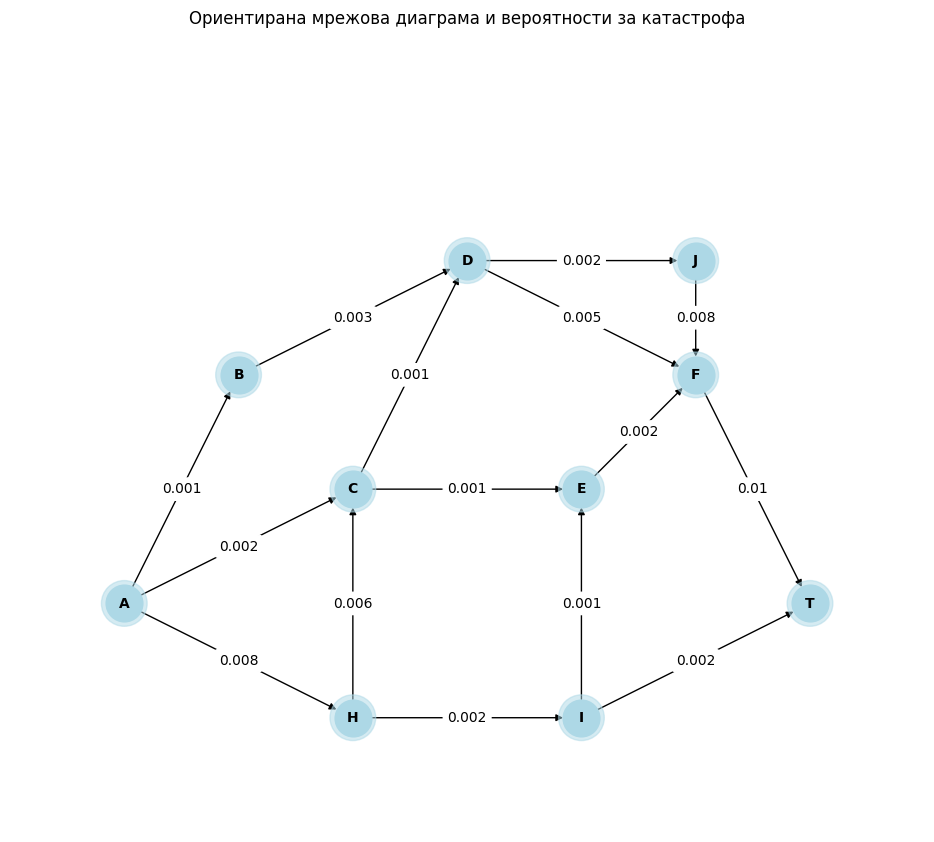

In [13]:
plt.figure(figsize=(10, 8))
nx.draw(G, pos=positions, with_labels=True, node_size=700, node_color='lightblue', font_size=10, font_weight='bold', arrows=True)
# Рисуваме етикетите на дъгите
edge_labels = nx.get_edge_attributes(G, 'Probability')

nx.draw_networkx_edge_labels(G, pos=positions, edge_labels=edge_labels, rotate=False)

# Рисуваме кръгове около възлите
for node, (x, y) in positions.items():
    circle = mpatches.Circle((x, y), radius=0.2, color='lightblue', alpha=0.5)
    plt.gca().add_patch(circle)

# Задаваме граници и аспект
plt.xlim(-1, 7)
plt.ylim(-2, 5)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Ориентирана мрежова диаграма и вероятности за катастрофа')
plt.grid()
plt.show()

Искаме да намерим най-безопасния маршрут. Това означава, че трябва да максимизираме вероятността да **няма** катастрофа. В набора от данни имаме вероятности за събитието "катастрофа" по отделните пътища.

Нека с $P(A_{s,e})$ означим вероятността за катастрофа по пътя с начало $s$ и край $e$. Катастрофите по различните отсечки са независими, затова вероятността да **няма** катастрофа е произведението от вероятностите да **няма** катастрофа на всяка отделна отсечка.

In [14]:
probs = np.array([0.008, 0.002, 0.002])
np.exp(np.log((1 - probs)).sum())

np.float64(0.988035968)

In [15]:
# Създаваме нов модел за най-безопасния маршрут
# Цел: максимизиране на вероятността за безопасност

import numpy as np

m1 = gp.Model("SafestPath")

# Създаваме променливи за всяка дъга
y = m1.addVars(dt.index, vtype=GRB.BINARY, name="y")

# За максимизиране на произведението на вероятности,
# работим с логаритми: max sum(log(1 - p_i)) * y_ij
prob_dict = {(u, v): dt.loc[(u, v), 'Probability'] for u, v in dt.index}
log_safety = {key: np.log(1 - prob) for key, prob in prob_dict.items()}

m1.setObjective(y.prod(log_safety), GRB.MAXIMIZE)

# Добавяме същите ограничения за потока
for node in nodes:
    if node == 'A':  # Изходен възел
        m1.addConstr(y.sum(node, '*') == 1, name=f"source_{node}")
    elif node == 'G':  # Краен възел
        m1.addConstr(y.sum('*', node) == 1, name=f"sink_{node}")
    else:
        m1.addConstr(y.sum(node, '*') == y.sum('*', node), name=f"flow_{node}")
        m1.addConstr(y.sum(node, '*') <= 1, name=f"outflow_{node}")
        m1.addConstr(y.sum('*', node) <= 1, name=f"inflow_{node}")

m1.optimize()

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 24.04.4 LTS")

CPU model: Intel(R) Core(TM) i9-14900K, instruction set [SSE2|AVX|AVX2]
Thread count: 32 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 28 rows, 15 columns and 57 nonzeros (Max)
Model fingerprint: 0xbfdb8646
Model has 15 linear objective coefficients
Variable types: 0 continuous, 15 integer (15 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e-03, 1e-02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]

Presolve removed 23 rows and 11 columns
Presolve time: 0.00s

Explored 0 nodes (0 simplex iterations) in 0.00 seconds (0.00 work units)
Thread count was 1 (of 32 available processors)

Solution count 0
No other solutions better than -1e+100

Model is infeasible
Best objective -, best bound -, gap -


In [16]:
# Отпечатваме резултатите

if m1.status == GRB.OPTIMAL:
    print('Намерен е оптимален безопасен маршрут:')
    print(f'Логаритъм на безопасностът: {m1.objVal}')
    print(f'Вероятност да няма катастрофа: {np.exp(m1.objVal):.4f}')
    print()
    total_distance = 0
    print('Маршрут:')
    for u, v in dt.index:
        if y[u, v].x > 0.5:
            distance = dt.loc[(u, v), 'Distance']
            prob = dt.loc[(u, v), 'Probability']
            total_distance += distance
            print(f'  {u} -> {v}: далжина = {distance}, вероятност за катастрофа = {prob}')
    print(f'\nОбща далжина: {total_distance}')
else:
    print('Не е намерен оптимално решение.')

Не е намерен оптимално решение.
